In [1]:
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.manifold import TSNE
from sklearn.metrics import (
    PrecisionRecallDisplay,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    RocCurveDisplay,
    roc_curve,
)

import plotly.express as px

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import Config, LossType


warnings.simplefilter(action="ignore", category=FutureWarning)

# Train Model

In [2]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")

logging.getLogger().setLevel(logging.DEBUG)
config = Config()
config.run.take_negative_samples = True
config.run.balanced_labels = False

config.training.seed = 42
config.graph.seed_graph_sampling = 42
config.graph.current_graph = "DrugBank_CRESCENDDI"

config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.run.upsample_negative_labels = False

config.run.pos_loss_multiplier = 0.5   
print(f"Running with pos_loss_multiplier={config.run.pos_loss_multiplier}")
run = main(config)
logging.getLogger().setLevel(logging.WARNING)


Running with pos_loss_multiplier=0.5
Current graph: DrugBank_CRESCENDDI


2026-02-23 08:46:39,535 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-02-23 08:46:39,670 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-02-23 08:46:39,671 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-02-23 08:46:39,727 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-02-23 08:46:51,872 - DEBUG - Early stopping at epoch 26


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


In [3]:
vars = run
graph_with_emb = vars["data"]
model = vars["model"]
node_id_map = vars["node_id_map"]
reversed_node_id_map = {v: k for k, v in node_id_map.items()}

# Visualize learned embeddings

In [4]:
def get_node_embeddings(model, data):
    model.eval()
    with torch.no_grad():
        node_embeddings = model.encode(data.x, data.edge_index)
    node_embeddings = node_embeddings.cpu().numpy()
    return node_embeddings


def get_reduced_embeddings(node_embeddings):
    # Initialize t-SNE with 2 components for 2D visualization
    tsne = TSNE(n_components=2)  # , random_state=42) # 42

    # Apply t-SNE to the drug embeddings
    reduced_embeddings = tsne.fit_transform(node_embeddings)

    return pd.DataFrame(reduced_embeddings, columns=["TSNE-1", "TSNE-2"])


def plot_embeddings(reduced_embeddings_df):
    # Create a scatter plot using Plotly
    fig = px.scatter(
        reduced_embeddings_df,
        x="TSNE-1",
        y="TSNE-2",
        # use hover_data to show drug IDs
        hover_data=[reduced_embeddings_df.index],
        title="t-SNE Visualization of Drug Embeddings",
        width=800,
        height=600,
    )
    fig.show()
    # return fig

In [5]:
embedding = get_node_embeddings(model, graph_with_emb)
embedding = get_reduced_embeddings(embedding)
embedding.index = embedding.index.map(lambda x: reversed_node_id_map.get(int(x), f"unknown_{int(x)}"))


In [6]:
plot_embeddings(embedding)

# Analyze Overall Score

In [7]:
# find optimal prediction threshold
def find_optimal_threshold(y_true, y_scores):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

    optimal_idx = f1_scores.argmax()
    current_threshold = thresholds[optimal_idx]
    return current_threshold


def find_balanced_threshold(y_scores):
    """
    Choose a threshold so that the number of predicted positives
    (y_scores >= threshold) is as close as possible to the number
    of predicted negatives (y_scores < threshold).
    """
    y_scores = np.asarray(y_scores).ravel()
    return float(np.median(y_scores))

# print confusion matrix at optimal threshold
def confusion_matrix_at_threshold(y_true, y_scores, current_threshold):
    y_pred = (y_scores >= current_threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    cm_string = "[tn, fp]\n[fn, tp]\n"
    print("Confusion Matrix:")
    print(cm_string)
    print(cm)



def get_f1_at_threshold(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)
    f1 = f1_score(y_true, y_pred)
    return f1

def plot_precision_recall_curve_with_thresholds(y_true, y_scores, current_threshold=None):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    fig, ax = plt.subplots()
    disp = PrecisionRecallDisplay(precision=precisions, recall=recalls)
    disp.plot(ax=ax)
    ax.set_title("Precision-Recall Curve with Thresholds")

    # Plot thresholds as colored points
    norm = plt.Normalize(thresholds.min(), thresholds.max())
    cmap = plt.get_cmap("viridis")
    sc = ax.scatter(recalls[1:], precisions[1:], c=thresholds, cmap=cmap, norm=norm, s=30, label=None)

    cbar = fig.colorbar(sc, ax=ax, label="Threshold")

    # Mark the optimal threshold
    if current_threshold is not None:
        idx = np.argmin(np.abs(thresholds - current_threshold))
        ax.scatter(
            recalls[idx + 1],
            precisions[idx + 1],
            color="red",
            s=80,
            edgecolor="black",
            label=f"Current: {current_threshold:.5f}",
        )
        ax.legend()

    plt.show()
def plot_roc_curve_with_thresholds(y_true, y_scores, current_threshold=None):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fig, ax = plt.subplots()
    disp = RocCurveDisplay(fpr=fpr, tpr=tpr)
    disp.plot(ax=ax)
    ax.set_title("ROC Curve with Thresholds")

    # roc_curve returns thresholds with first value typically = inf; ignore it for coloring/markers
    fpr_plot = fpr[1:]
    tpr_plot = tpr[1:]
    thr_plot = thresholds[1:]
    if thr_plot.size > 0:
        norm = plt.Normalize(thr_plot.min(), thr_plot.max())
        cmap = plt.get_cmap("viridis")
        sc = ax.scatter(fpr_plot, tpr_plot, c=thr_plot, cmap=cmap, norm=norm, s=30, label=None)
        fig.colorbar(sc, ax=ax, label="Threshold")

    # Mark the optimal threshold (if provided)
    if current_threshold is not None and thr_plot.size > 0:
        idx = np.argmin(np.abs(thr_plot - float(current_threshold)))
        ax.scatter(
            fpr_plot[idx],
            tpr_plot[idx],
            color="red",
            s=80,
            edgecolor="black",
            label=f"Current: {float(current_threshold):.5f}",
        )
        ax.legend()

    plt.show()



In [8]:
test_data = vars["test_data"]
test_scores = vars["test_scores"]

Optimal threshold: 0.4999886751174927
Balanced threshold: 0.5001301765441895
Confusion Matrix:
[tn, fp]
[fn, tp]

[[ 651  105]
 [4729 5292]]


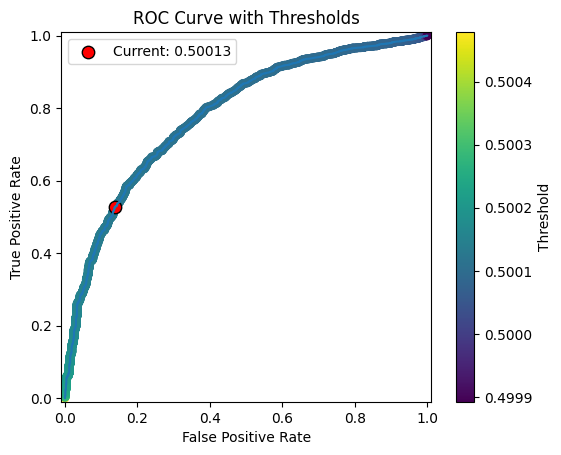

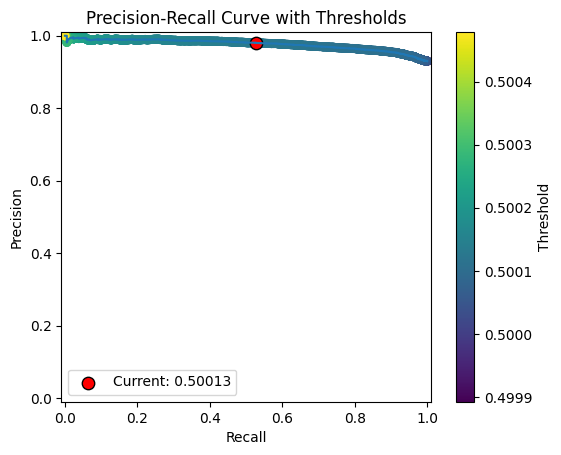

ROC_AUC: 0.7824
PR_AUC: 0.9764


In [9]:
y_true = test_data.edge_label.cpu().numpy()
optimal_threshold = find_optimal_threshold(y_true, test_scores)
balanced_threshold = find_balanced_threshold(test_scores)
print(f"Optimal threshold: {optimal_threshold}")
print(f"Balanced threshold: {balanced_threshold}")

current_threshold = balanced_threshold


confusion_matrix_at_threshold(y_true, test_scores, current_threshold)
#f1_at_optimal = get_f1_at_threshold(y_true, test_scores, current_threshold)
#print(f"F1 Score at optimal threshold: {f1_at_optimal}")
plot_roc_curve_with_thresholds(y_true, test_scores, current_threshold)
plot_precision_recall_curve_with_thresholds(y_true, test_scores, current_threshold)

print(f"ROC_AUC: {vars['metrics']['AUC_mean']:.4f}")
print(f"PR_AUC: {vars['metrics']['PR_AUC_mean']:.4f}") 

In [10]:
print(str(config.run).replace(',', ',\n'))

RunSettings(take_negative_samples=True,
 balanced_labels=False,
 upsample_negative_labels=False,
 use_only_sampled_negatives_in_train=False,
 loss_type=<LossType.WeightedBCEWithLogitsLoss: 'WeightedBCEWithLogitsLoss'>,
 pos_loss_multiplier=0.5,
 focal_loss_gamma=2.0)


# Per Drug Analysis

In [11]:
def compute_per_drug_f1_scores(test_data, test_scores, reversed_node_id_map, optimal_threshold):
    edge_idx = test_data.edge_label_index.cpu().numpy()  # shape (2, E)
    y_true = test_data.edge_label.cpu().numpy().astype(int)  # shape (E,)
    y_scores = np.asarray(test_scores)
    thr = float(optimal_threshold)

    src, dst = edge_idx[0], edge_idx[1]
    all_nodes = np.unique(np.concatenate([src, dst]))

    rows = []
    for node in all_nodes:
        drug_id = reversed_node_id_map.get(int(node))
        if drug_id is None:
            print(f"Warning: Node {node} not found in reversed_node_id_map.")
            continue
        mask = (src == node) | (dst == node)
        if not np.any(mask):
            print(f"Warning: No edges found for node {node} (drug_id: {drug_id}).")
            continue
        yt = y_true[mask]
        ys = y_scores[mask]
        yp = (ys >= thr).astype(int)
        f1 = f1_score(yt, yp, zero_division=0)
        rows.append({"drug_id": drug_id, "n_edges": int(mask.sum()), "f1": float(f1)})

    per_drug_f1 = pd.DataFrame(rows).sort_values(["f1", "n_edges"], ascending=[False, False])
    # display(per_drug_f1)
    return per_drug_f1


per_drug_f1 = compute_per_drug_f1_scores(test_data, test_scores, reversed_node_id_map, optimal_threshold=balanced_threshold)
per_drug_f1["index"] = per_drug_f1["drug_id"].map(
    lambda x: list(node_id_map.keys()).index(x) if x in node_id_map else -1
)
per_drug_f1.set_index("index", inplace=True)

In [12]:
per_drug_f1.sort_values(by=["n_edges", 'drug_id'], ascending=False).to_csv("per_drug_f1_scores.csv")

In [13]:
per_drug_f1['f1'].mean()

0.4001489162371327

In [14]:
DRUG_OF_INTEREST = "DB00749"


def confusion_matrix_for_drug(drug_id, test_data, test_scores, reversed_node_id_map, optimal_threshold):
    node_id = None
    for k, v in reversed_node_id_map.items():
        if v == drug_id:
            node_id = k
            break
    if node_id is None:
        print(f"Drug ID {drug_id} not found.")
        return

    edge_idx = test_data.edge_label_index.cpu().numpy()  # shape (2, E)
    y_true = test_data.edge_label.cpu().numpy().astype(int)  # shape (E,)
    y_scores = np.asarray(test_scores)
    thr = float(optimal_threshold)

    src, dst = edge_idx[0], edge_idx[1]
    mask = (src == node_id) | (dst == node_id)
    if not np.any(mask):
        print(f"No edges found for drug ID {drug_id}.")
        return

    yt = y_true[mask]
    ys = y_scores[mask]
    yp = (ys >= thr).astype(int)

    cm = confusion_matrix(yt, yp)
    cm_string = "[tn, fp]\n[fn, tp]\n"
    print(f"Confusion Matrix for drug ID {drug_id}:")
    print(cm_string)
    print(cm)


def confusion_matrix_for_drug_for_all_possible_edges(drug_id, data, model, reversed_node_id_map, threshold):
    # map external ID -> internal idx
    node_id = None
    for k, v in reversed_node_id_map.items():
        if v == drug_id:
            node_id = k
            break
    if node_id is None:
        print(f"Drug ID {drug_id} not found.")
        return

    device = next(model.parameters()).device
    node_id_t = torch.tensor(node_id, dtype=torch.long, device=device)

    # Candidate edges: node_id to all others (exclude self)
    all_targets = torch.arange(data.num_nodes, device=device, dtype=torch.long)
    mask_not_self = all_targets != node_id_t
    all_targets = all_targets[mask_not_self]
    srcs = torch.full_like(all_targets, node_id_t)
    edge_index_candidate = torch.stack([srcs, all_targets], dim=0)  # shape [2, N-1]

    # Encode with the TRUE graph, not the candidate edges
    model.eval()
    with torch.no_grad():
        z = model.encode(data.x.to(device), data.edge_index.to(device))
        logits = model.decode(z, edge_index_candidate).view(-1)
        global probs
        probs = logits.sigmoid().detach().cpu().numpy()

    # Build y_true: 1 if (node_id, t) is an edge in the TRUE graph (undirected)
    ei = data.edge_index.cpu().numpy()
    src, dst = ei[0], ei[1]
    # neighbors of node_id (treat as undirected)
    neighbors = set(dst[src == node_id].tolist()) | set(src[dst == node_id].tolist())
    targets_cpu = all_targets.cpu().numpy()
    y_true = np.array([1 if int(t) in neighbors else 0 for t in targets_cpu], dtype=int)

    # Predictions at threshold
    y_pred = (probs >= float(threshold)).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix for drug ID", drug_id, "(all possible edges):")
    print("[tn, fp]\n[fn, tp]\n")
    print(cm)


confusion_matrix_for_drug(DRUG_OF_INTEREST, test_data, test_scores, reversed_node_id_map, optimal_threshold=optimal_threshold)
confusion_matrix_for_drug_for_all_possible_edges(
    DRUG_OF_INTEREST, vars["data"], vars["model"], reversed_node_id_map, threshold=optimal_threshold
)

Confusion Matrix for drug ID DB00749:
[tn, fp]
[fn, tp]

[[ 0  2]
 [ 0 35]]
Confusion Matrix for drug ID DB00749 (all possible edges):
[tn, fp]
[fn, tp]

[[  61 1283]
 [   0  171]]


# Test Results

In [15]:
test_data = vars["test_data"]
test_scores = vars["test_scores"]
node_id_map = vars["node_id_map"]
reversed_node_id_map = {v: k for k, v in node_id_map.items()}


In [16]:
class_map = {(1,1): 'TP', (0,0): 'TN', (1,0): 'FN', (0,1): 'FP'}
threshold = balanced_threshold
    
edges_df = pd.DataFrame(test_data.edge_label_index.cpu().t()).map(lambda x: reversed_node_id_map[x])
edges_df = edges_df.rename(columns={0: "source", 1: "target"})
edges_df['gt_label'] = test_data.edge_label.cpu().numpy().astype(int)
edges_df['pred_score'] = (test_scores >= threshold).astype(int)
edges_df['pred_class'] = [class_map[(gt, pred)] for gt, pred in zip(edges_df['gt_label'], edges_df['pred_score'])]
# make bidirectional
edges_df = pd.concat([edges_df, edges_df.rename(columns={"source": "target", "target": "source"})])
edges_df = pd.concat([edges_df, pd.get_dummies(edges_df['pred_class'])], axis=1)

print(f"negative classifications: {edges_df['FN'].sum() + edges_df['TN'].sum()}")

negative classifications: 10760


In [17]:
edges_df = edges_df.groupby('source').sum()[['TP', 'TN', 'FP', 'FN']]
edges_df['count'] = edges_df.sum(axis=1)
edges_df['perc_missclassified'] = (edges_df['FP'] + edges_df['FN']) / edges_df['count'] * 100
edges_df['balanced_error_rate'] = 0.5 * (edges_df['FP'] / (edges_df['FP'] + edges_df['TN'] + 1e-10) + edges_df['FN'] / (edges_df['TP'] + edges_df['FN'] + 1e-10))
print(f"threshold used: {threshold}")
print(f"negative classifications: {edges_df['FN'].sum() + edges_df['TN'].sum()}")

threshold used: 0.5001301765441895
negative classifications: 10760


In [18]:
node_info_trained = edges_df.copy()

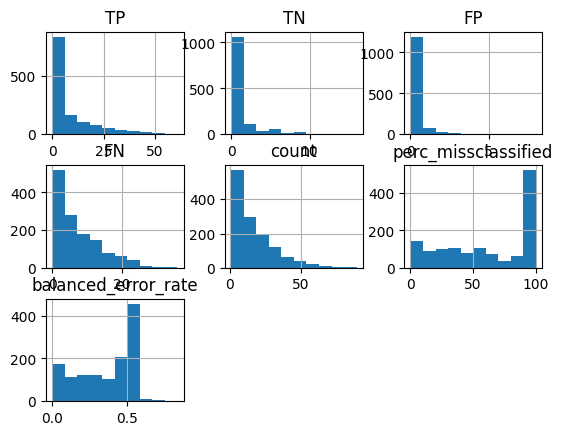

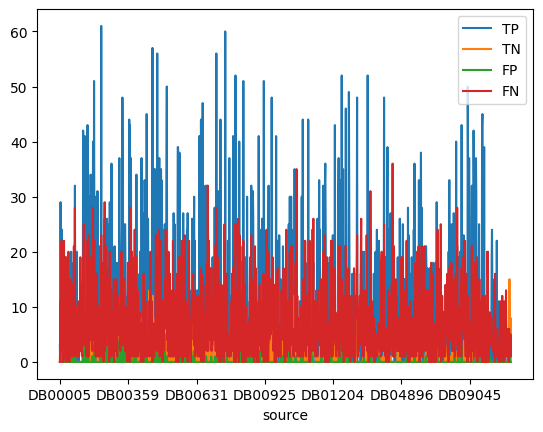

In [19]:
edges_df.hist()
plt.show()
edges_df[['TP', 'TN', 'FP', 'FN']].plot()
plt.show()

# Visualize Edges

probs
import plotly.graph_objects as go
fig = go.Figure(data=[go.Histogram(x=probs, nbinsx=50)])
fig.update_layout(
    title="Histogram of Predicted Probabilities for All Possible Edges from Drug 'DB08932'",
    xaxis_title="Predicted Probability",
    yaxis_title="Count",
    width=800,
    height=500
)
fig.show()

## Use original embeddings

In [20]:
# use original embedding if disered
path = "/data/giobbi/embeddings/DESC_GPT.csv"
original_embedding = pd.read_csv(path, sep="\t", index_col=0)
original_embedding.set_index(original_embedding.columns[0], inplace=True)
original_embedding

# make tsne
original_embedding.select_dtypes(include=["float64", "float32"])
tsne = TSNE(n_components=2)
reduced_original_embedding = tsne.fit_transform(original_embedding.select_dtypes(include=["float64", "float32"]))
reduced_original_embedding_df = pd.DataFrame(reduced_original_embedding, columns=["TSNE-1", "TSNE-2"])
reduced_original_embedding_df.index = original_embedding.index

# join original_embedding_df to embedding
embedding = embedding.join(reduced_original_embedding_df, lsuffix="_GNN", rsuffix="_Original")

In [21]:
# overwrite TSNE-1 and TSNE-2 columns with desired values
embedding["TSNE-1"] = embedding["TSNE-1_Original"]
embedding["TSNE-2"] = embedding["TSNE-2_Original"]
embedding

,TSNE-1_GNN,TSNE-2_GNN,TSNE-1_Original,TSNE-2_Original,TSNE-1,TSNE-2
DB00005,-15.059788,32.856335,25.936787,-42.288208,25.936787,-42.288208
DB00006,22.593485,39.664661,0.288924,-38.697357,0.288924,-38.697357
DB00007,49.659908,-11.754347,49.944542,46.783989,49.944542,46.783989
DB00008,3.343104,27.868856,3.647313,-57.181187,3.647313,-57.181187
DB00009,22.585724,39.349464,-4.377208,-40.772491,-4.377208,-40.772491
...,...,...,...,...,...,...
DB13872,-24.691626,-6.979817,-0.357226,73.945618,-0.357226,73.945618
DB13878,-45.078209,-5.418837,-6.413913,-59.518097,-6.413913,-59.518097
DB13879,-43.850906,-5.701054,-6.156215,-59.767181,-6.156215,-59.767181
DB13919,5.974087,1.646358,-2.711850,27.012836,-2.711850,27.012836


## Additional Descriptions Features

In [22]:
feature_path = "/data/giobbi/embeddings/not_aligned_with_model/drug_description_enriched.csv"
additional_description_features = pd.read_csv(feature_path, sep="\t", index_col=0)

In [23]:
node_info_trained['perc_neg_gt'] = ( node_info_trained['FP'] + node_info_trained['TN'] ) / node_info_trained['count'] * 100


In [24]:
# Reset embedding to clean state before joining
embedding = get_reduced_embeddings(get_node_embeddings(model, graph_with_emb))
embedding.index = embedding.index.map(lambda x: reversed_node_id_map.get(int(x), f"unknown_{int(x)}"))

# Now join the additional features
embedding = embedding.join(
    additional_description_features.set_index("Drug ID"),
    how="left",
)

embedding = embedding.join(
    node_info_trained[["perc_missclassified", "balanced_error_rate", "count", "perc_neg_gt"]].rename(columns={
        "count": "edge_count",
    }),
    how="left",
)

embedding = embedding[embedding['edge_count'] > 5]

In [25]:
embedding

,TSNE-1,TSNE-2,Drug Name,Discription,Description_Masked,drug_unique_count,drug_count,pharma_class,perc_missclassified,balanced_error_rate,edge_count,perc_neg_gt
DB00006,6.936172,-38.724171,Bivalirudin,Bivalirudin is a synthetic 20 residue peptide ...,<DRUG> is a synthetic 20 residue peptide (<DRU...,2,4,2,100.000000,0.500000,6.0,0.000000
DB00007,34.399986,29.940905,Leuprolide,Leuprolide is a synthetic 9-residue peptide an...,<DRUG> is a synthetic 9-residue peptide analog...,1,4,9,27.500000,0.137500,40.0,0.000000
DB00009,6.790408,-39.089027,Alteplase,Alteplase is a recombinant tissue plasminogen ...,<DRUG> is a recombinant tissue <DRUG> activato...,6,14,23,87.500000,0.500000,24.0,12.500000
DB00013,7.379254,-38.637604,Urokinase,Urokinase is an endogenous peptide that is cle...,<DRUG> is an endogenous peptide that is cleave...,3,5,23,100.000000,0.500000,22.0,0.000000
DB00014,35.236717,29.320021,Goserelin,"Goserelin is a synthetic hormone. In men, it s...","<DRUG> is a synthetic hormone. In men, it stop...",3,4,10,35.135135,0.175676,37.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
DB11181,64.363708,6.013774,Homatropine,Homatropine is an anticholinergic drug that ac...,<DRUG> is an anticholinergic drug that acts as...,4,6,6,100.000000,0.500000,6.0,0.000000
DB11637,-2.191557,6.152582,Delamanid,Delamanid is an anti-tuberculosis agent derive...,<DRUG> is an anti-tuberculosis agent derived f...,3,7,1,75.000000,0.500000,8.0,25.000000
DB13792,2.506762,-17.697611,Clopamide,Clopamide is an oral diuretic agent with antih...,<DRUG> is an oral diuretic agent with antihype...,1,1,2,100.000000,0.500000,6.0,0.000000
DB13867,10.139986,0.670083,Fluticasone,Fluticasone is a synthetic glucocorticoid avai...,<DRUG> is a synthetic glucocorticoid available...,3,5,12,16.666667,0.531250,18.0,88.888889


In [38]:
# Check correlation between features and model performance
correlation_analysis = embedding[['perc_missclassified', 'balanced_error_rate', 'perc_neg_gt', 'drug_unique_count', 'edge_count']].corr()
print(correlation_analysis)

# Also check by pharma_class
print(embedding.groupby('pharma_class')[['balanced_error_rate', 'perc_missclassified']].agg(['mean', 'std', 'count']))

                     perc_missclassified  balanced_error_rate  perc_neg_gt  \
perc_missclassified             1.000000             0.834885    -0.152480   
balanced_error_rate             0.834885             1.000000     0.142738   
perc_neg_gt                    -0.152480             0.142738     1.000000   
drug_unique_count              -0.001137             0.024660     0.050887   
edge_count                     -0.421745            -0.234249    -0.029821   

                     drug_unique_count  edge_count  
perc_missclassified          -0.001137   -0.421745  
balanced_error_rate           0.024660   -0.234249  
perc_neg_gt                   0.050887   -0.029821  
drug_unique_count             1.000000    0.055441  
edge_count                    0.055441    1.000000  
             balanced_error_rate                     perc_missclassified  \
                            mean           std count                mean   
pharma_class                                                 

In [26]:
hover_data = [
        embedding.index,
        "pharma_class",
        "Drug Name",
        #'Discription',
        "drug_count",
        "drug_unique_count",
        "perc_missclassified",
        "edge_count",
        "perc_neg_gt"
    ]

In [40]:
import plotly.express as px

# Use size for one metric, color for another
fig = px.scatter(
    embedding,
    x="TSNE-1",
    y="TSNE-2",
    color="balanced_error_rate",
    size="edge_count",  # Node size encodes edge frequency
    hover_data=hover_data,
    color_continuous_scale="RdYlGn_r",
    title="t-SNE: Color=Error Rate, Size=Edge Count",
    width=900,
    height=700,
)
fig.show()

In [41]:
# Filter to classes with sufficient samples
top_classes = embedding['pharma_class'].value_counts().head(6).index
embedding_filtered = embedding[embedding['pharma_class'].isin(top_classes)]

fig = px.scatter(
    embedding_filtered,
    x="TSNE-1",
    y="TSNE-2",
    color="balanced_error_rate",
    facet_col="pharma_class",
    facet_col_wrap=3,
    color_continuous_scale="RdYlGn_r",
    hover_data=["drug_unique_count", "edge_count"],
    height=900,
    width=1200,
)
fig.show()

In [42]:
# Flag high-error drugs
high_error = embedding[embedding['balanced_error_rate'] > embedding['balanced_error_rate'].quantile(0.75)]
print(f"High error rate drugs ({len(high_error)}):")
print(high_error[['pharma_class', 'balanced_error_rate', 'edge_count', 'drug_unique_count']].sort_values('balanced_error_rate', ascending=False).head(10))

# Check if they share characteristics
print("\nCommon pharma classes in high-error group:")
print(high_error['pharma_class'].value_counts())

High error rate drugs (205):
         pharma_class  balanced_error_rate  edge_count  drug_unique_count
DB00674            14             0.833333        22.0                  2
DB09242             2             0.800000        16.0                  2
DB00932             4             0.755319        48.0                  2
DB01263             1             0.729730        38.0                  1
DB01023             2             0.722222        19.0                  2
DB06723             2             0.692308        30.0                  2
DB00790             2             0.681818        26.0                  4
DB01045             3             0.673077        53.0                  0
DB00196             1             0.669231        67.0                  4
DB00564            17             0.666667        58.0                  1

Common pharma classes in high-error group:
pharma_class
23    45
2     38
3     19
6     13
19    10
7      8
10     8
4      8
5      8
8      7
9      7
2

In [45]:
# Create derived features that may reveal patterns
embedding['error_per_edge'] = embedding['perc_missclassified'] / (embedding['edge_count'] + 1)
embedding['is_high_error'] = embedding['balanced_error_rate'] > embedding['balanced_error_rate'].median()

# Visualize with this categorical feature
fig = px.scatter(
    embedding,
    x="TSNE-1",
    y="TSNE-2",
    color="is_high_error",
    size="edge_count",
    hover_name=embedding.index,
    hover_data=['pharma_class', 'balanced_error_rate'],
    title="High vs Low Error Rate Drugs",
    width=900,
    height=700,
)
fig.show()

In [27]:
color_sequence = px.colors.qualitative.Set2_r


bins = [0, 1, 2, 4, 7, 10, 11]
count_bins = pd.cut(embedding["drug_unique_count"], bins=bins, right=False)

fig = px.scatter(
    embedding,
    x="TSNE-1",
    y="TSNE-2",
    color_continuous_scale=[(0, "green"), (0.5, "white"), (1, "red")],
    range_color=[0, 100],
    color=embedding["perc_missclassified"],  # embedding["pharma_class"],  # embedding['drug_unique_count'],
    #color_discrete_sequence=color_sequence,
    # use hover_data to show drug IDs
    hover_data=hover_data,
    title="t-SNE Visualization of Drug Embeddings with Unique Drug Count",
    width=800,
    height=600,
)
fig.show()

In [32]:
color_sequence = px.colors.qualitative.Set2_r


bins = [0, 1, 2, 4, 7, 10, 11]

fig = px.scatter(
    embedding,
    x="TSNE-1",
    y="TSNE-2",
    color_continuous_scale=[(0, "green"), (0.5, "white"), (1, "red")],
    color=embedding["balanced_error_rate"],  # embedding["pharma_class"],  # embedding['drug_unique_count'],
    #color_discrete_sequence=color_sequence,
    # use hover_data to show drug IDs
    hover_data=hover_data,
    title="t-SNE Visualization of Drug Embeddings with Unique Drug Count",
    width=800,
    height=600,
)
fig.show()

fig.write_html("tsne_visualization_with_balanced_error_rate.html")

In [29]:
color_sequence = px.colors.qualitative.Set2_r


bins = [0, 1, 2, 4, 7, 10, 11]
count_bins = pd.cut(embedding["drug_unique_count"], bins=bins, right=False)

fig = px.scatter(
    embedding,
    x="TSNE-1",
    y="TSNE-2",
    color_continuous_scale=[(0, "green"), (0.5, "white"), (1, "red")],
    color=embedding["perc_neg_gt"],  # embedding["pharma_class"],  # embedding['drug_unique_count'],
    #color_discrete_sequence=color_sequence,
    # use hover_data to show drug IDs
    hover_data=hover_data,
    title="t-SNE Visualization of Drug Embeddings with Unique Drug Count",
    width=800,
    height=600,
)
fig.show()

In [30]:
color_sequence = px.colors.qualitative.Set1


bins = [0, 1, 2, 4, 7, 10, 11]
count_bins = pd.cut(embedding["drug_unique_count"], bins=bins, right=False)


fig = px.scatter(
    embedding,
    x="TSNE-1",
    y="TSNE-2",
    color=embedding["pharma_class"],  # embedding['drug_unique_count'],
    color_discrete_sequence=color_sequence,
    # use hover_data to show drug IDs
    hover_data=hover_data,
    title="t-SNE Visualization of Drug Embeddings with Unique Drug Count",
    width=800,
    height=600,
)
fig.show()

In [34]:
summary = (
    embedding.groupby("pharma_class")
    .agg(
        balanced_error_rate_mean=("balanced_error_rate", "mean"),
        perc_missclassified_mean=("perc_missclassified", "mean"),
        perc_neg_gt_mean=("perc_neg_gt", "mean"),
        count=("balanced_error_rate", "count"),
    )
    .sort_values(by="balanced_error_rate_mean", ascending=False)
)
display(summary[summary['count'] > 5])


,balanced_error_rate_mean,perc_missclassified_mean,perc_neg_gt_mean,count
pharma_class,,,,
3,0.428067,67.474754,14.142954,48
22,0.423808,83.007217,1.754386,19
19,0.423122,78.368775,6.671794,28
20,0.423011,59.903711,26.320357,15
10,0.405785,75.330938,0.601775,17
15,0.394498,74.232952,3.842278,9
8,0.384849,70.055005,7.454975,19
2,0.379563,62.287215,9.884672,104
18,0.371272,47.698665,15.142190,7


In [35]:
df = summary

In [37]:
# histogram of balanced_error_rate_mean
fig = px.histogram(
    df,
    x="balanced_error_rate_mean",
    nbins=20,
    title="Distribution of Balanced Error Rate Mean by Pharma Class",
    width=800,
    height=600,
)
fig.show()

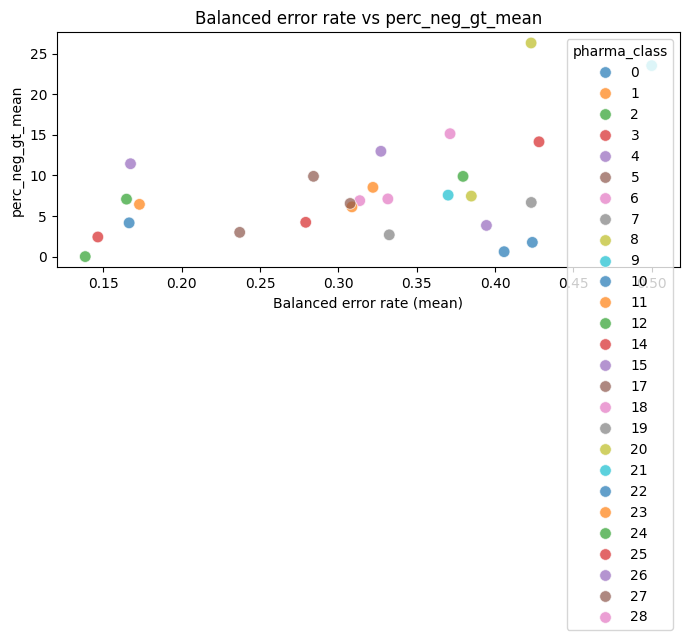

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# columns
x = 'balanced_error_rate_mean'
y = 'perc_neg_gt_mean'

# ensure numeric and drop missing
df[[x, y]] = df[[x, y]].apply(pd.to_numeric, errors='coerce')
plot_df = df.dropna(subset=[x, y])

# plot
plt.figure(figsize=(7,5))
sns.scatterplot(data=plot_df, x=x, y=y, hue='pharma_class', alpha=0.7, s=70, palette='tab10', legend='brief')
plt.xlabel('Balanced error rate (mean)')
plt.ylabel('perc_neg_gt_mean')
plt.title('Balanced error rate vs perc_neg_gt_mean')
plt.tight_layout()
plt.show()

## Visualize Edges


In [25]:
threshold = balanced_threshold
test_scores = vars["test_scores"]

In [26]:
data = vars["test_data"]
NUMBER_OF_EDGES = 500


In [27]:
# Select one drug and analyze its edges
most_frequent_drugs = (
    pd.Series(list(data.edge_label_index[0].cpu().numpy()) + list(data.edge_label_index[1].cpu().numpy()))
    .value_counts()
    .head(10)
)
display(most_frequent_drugs)
display(per_drug_f1)

521     89
150     86
584     78
123     76
1068    73
610     73
551     72
126     71
924     71
971     71
Name: count, dtype: int64

,drug_id,n_edges,f1
index,,,
320,DB00450,59,1.0
1351,DB09034,50,1.0
248,DB00366,43,1.0
1402,DB09117,43,1.0
714,DB00972,41,1.0
...,...,...,...
1484,DB10283,1,0.0
1486,DB10631,1,0.0
1504,DB11574,1,0.0


In [28]:
idx = 795
# get all positions where either source or target is idx
idcs = ((data.edge_label_index[0] == idx) | (data.edge_label_index[1] == idx)).nonzero(as_tuple=True)[0]
idcs = idcs.cpu().numpy()
idcs

array([ 3612,  3940,  4507,  5709,  5957,  6242,  7079,  7300,  8499,
        9429, 10039, 10070, 10188, 10229, 10245, 10272, 10395, 10544,
       10594, 10738])

In [29]:
# seed random number generator
# torch.manual_seed(44)
# idcs = torch.randperm(data.edge_label.size(0))[:NUMBER_OF_EDGES]
edge_label = data.edge_label[idcs]
edge_label_index = data.edge_label_index[:, idcs]


In [30]:
model.eval()
with torch.no_grad():
    # Step 1: Get node embeddings
    z = model.encode(data.x, data.edge_index)
    # Step 2: Predict edges (edge_label_index: shape [2, num_edges])
    logits = model.decode(z, edge_label_index).view(-1)
    probs = logits.sigmoid().cpu().numpy()  # Probabilities for each edge
    # Step 3: Apply threshold for binary prediction
    predicted_labels = (probs >= threshold).astype(int)  # Use your chosen threshold

In [31]:
# Convert the edge_label_index tensor (shape [2, num_edges]) to CPU numpy array
# then build list of (src_id, dst_id) using reversed_node_id_map.
edge_label_index_cpu = edge_label_index.cpu().numpy()  # shape (2, E)
edge_pairs = [
    (reversed_node_id_map.get(int(src)), reversed_node_id_map.get(int(dst)))
    for src, dst in edge_label_index_cpu.T  # iterate columns (E, 2)
]

In [32]:
def format_description(desc, max_length=60):
    # Insert <br> every max_length characters, or at sentence breaks
    import re

    if pd.isnull(desc):
        return ""
    # split every 20 characters
    sentences = re.findall(".{1,%d}" % max_length, desc)
    return "<br>".join(sentences)


embedding["Description_br"] = embedding["Discription"].apply(format_description)

customdata = (
    embedding[["drug_count", "pharma_class", "Description_br"]].values
    if "drug_count" in embedding.columns and "pharma_class" in embedding.columns
    else None
)

hovertemplate = (
    "Drug ID: %{text}"
    "<br>TSNE-1: %{x:.3f}"
    "<br>TSNE-2: %{y:.3f}"
    "<br>Drug Count: %{customdata[0]}"
    "<br>Pharma Class: %{customdata[1]}"
    "<br>Description: %{customdata[2]}"
    "<extra></extra>"
)

In [33]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Inputs assumed:
# embedding: pd.DataFrame with index of Drug IDs and columns ['TSNE-1', 'TSNE-2']
# edge_pairs: list[tuple[str, str]] of (src_id, dst_id) mapped to embedding.index
# edge_label: 1D tensor/array of 0/1 (ground truth) aligned with edge_pairs
# predicted_labels: 1D array of 0/1 aligned with edge_pairs

gt = np.asarray(edge_label.cpu().numpy() if hasattr(edge_label, "cpu") else edge_label).astype(int)
pred = np.asarray(predicted_labels).astype(int)
assert len(edge_pairs) == len(gt) == len(pred), "edge_pairs, gt, pred must have same length"

# Confusion categories
is_tp = (gt == 1) & (pred == 1)
is_fp = (gt == 0) & (pred == 1)
is_tn = (gt == 0) & (pred == 0)
is_fn = (gt == 1) & (pred == 0)

# Filter embedding to only nodes present in edges
nodes_in_edges = pd.Index(sorted({n for pair in edge_pairs for n in pair}))
embedding_sub = embedding.loc[embedding.index.intersection(nodes_in_edges)].copy()
embedding_sub["pharma_class"] = embedding_sub["pharma_class"].fillna("Unknown")

# Bin drug_unique_count for marker symbol
bins = [0, 1, 2, 4, 7, 10, 11]
count_bins = pd.cut(embedding_sub["drug_unique_count"], bins=bins, right=False)
symbols = ["circle", "square", "diamond", "cross", "x", "triangle-up"]
bin_to_symbol = {cat: sym for cat, sym in zip(count_bins.cat.categories, symbols)}

# Build color map for pharma_class
classes = embedding_sub["pharma_class"].astype(str).unique()
palette = px.colors.qualitative.Set1_r
color_map = {cls: palette[i % len(palette)] for i, cls in enumerate(sorted(classes))}

fig = go.Figure()

# Add node traces grouped by pharma_class and count_bin (marker symbol)
for cls in sorted(classes):
    for bin_cat in count_bins.cat.categories:
        mask = (embedding_sub["pharma_class"].astype(str) == cls) & (count_bins == bin_cat)
        df_sub = embedding_sub[mask]
        if df_sub.empty:
            continue
        node_x = df_sub["TSNE-1"].values
        node_y = df_sub["TSNE-2"].values
        node_ids = df_sub.index.astype(str).tolist()
        customdata_cls = df_sub[["drug_count", "pharma_class", "Description_br"]].values

        fig.add_trace(
            go.Scattergl(
                x=node_x,
                y=node_y,
                mode="markers",
                marker=dict(size=7, color=color_map[cls], symbol=bin_to_symbol[bin_cat]),
                text=node_ids,
                customdata=customdata_cls,
                hovertemplate=hovertemplate,
                name=f"{cls}, {bin_cat}",
            )
        )


def add_edge_lines(mask, color, name, dash="solid"):
    xs, ys = [], []
    for (src, dst), keep in zip(edge_pairs, mask):
        if not keep:
            continue
        if src not in embedding_sub.index or dst not in embedding_sub.index:
            continue
        x0, y0 = embedding_sub.loc[src, ["TSNE-1", "TSNE-2"]]
        x1, y1 = embedding_sub.loc[dst, ["TSNE-1", "TSNE-2"]]
        xs += [x0, x1, None]
        ys += [y0, y1, None]
    if xs:
        fig.add_trace(
            go.Scattergl(
                x=xs,
                y=ys,
                mode="lines",
                line=dict(color=color, width=1.0, dash=dash),
                name=name,
                hoverinfo="skip",
            )
        )


# Add edges by confusion class with requested colors/styles
add_edge_lines(is_tp, "rgba(0,180,0,0.85)", "TP (gt=1, pred=1)", dash="solid")
add_edge_lines(is_fn, "rgba(160,180,0,0.85)", "FN (gt=1, pred=0)", dash="dash")
add_edge_lines(is_tn, "rgba(220,20,60,0.85)", "TN (gt=0, pred=0)", dash="solid")
add_edge_lines(is_fp, "rgba(220,120,90,0.85)", "FP (gt=0, pred=1)", dash="dash")

fig.update_layout(
    title=f"t-SNE: TP={np.sum(is_tp)}, TN={np.sum(is_tn)}, FP={np.sum(is_fp)}, FN={np.sum(is_fn)}",
    width=950,
    height=750,
    legend=dict(itemsizing="constant"),
)
fig.show()

# print confusion matrix for this drug
drug_id = reversed_node_id_map[idx]
confusion_matrix_for_drug(drug_id, test_data, test_scores, reversed_node_id_map, threshold)

Confusion Matrix for drug ID DB01067:
[tn, fp]
[fn, tp]

[[10  0]
 [10  0]]


## All nodes

In [34]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

# Fill missing pharma_class
embedding["pharma_class"] = embedding["pharma_class"].fillna("Unknown")

# Build color map for pharma_class
classes = embedding["pharma_class"].astype(str).unique()
palette = px.colors.qualitative.Set1
color_map = {cls: palette[i % len(palette)] for i, cls in enumerate(sorted(classes))}

fig = go.Figure()

# Add node traces grouped and colored by pharma_class (legend per class)
for cls in sorted(classes):
    df_cls = embedding[embedding["pharma_class"].astype(str) == cls]
    node_x = df_cls["TSNE-1"].values
    node_y = df_cls["TSNE-2"].values
    node_ids = df_cls.index.astype(str).tolist()
    customdata_cls = df_cls[["drug_count", "pharma_class", "Description_br"]].values

    fig.add_trace(
        go.Scattergl(
            x=node_x,
            y=node_y,
            mode="markers",
            marker=dict(size=7, color=color_map[cls]),
            text=node_ids,
            customdata=customdata_cls,
            hovertemplate=hovertemplate,
            name=f"{cls}",
        )
    )

# --- Edge lines by confusion class (TP, FN, TN, FP) ---
# Compute confusion categories
# gt: ground truth, pred: predicted_labels
# edge_pairs, gt, pred must be aligned

gt = np.asarray(edge_label.cpu().numpy() if hasattr(edge_label, "cpu") else edge_label).astype(int)
pred = np.asarray(predicted_labels).astype(int)
assert len(edge_pairs) == len(gt) == len(pred), "edge_pairs, gt, pred must have same length"

is_tp = (gt == 1) & (pred == 1)
is_fp = (gt == 0) & (pred == 1)
is_tn = (gt == 0) & (pred == 0)
is_fn = (gt == 1) & (pred == 0)


def add_edge_lines(mask, color, name, dash="solid"):
    xs, ys = [], []
    for (src, dst), keep in zip(edge_pairs, mask):
        if not keep:
            continue
        if src not in embedding.index or dst not in embedding.index:
            continue
        x0, y0 = embedding.loc[src, ["TSNE-1", "TSNE-2"]]
        x1, y1 = embedding.loc[dst, ["TSNE-1", "TSNE-2"]]
        xs += [x0, x1, None]
        ys += [y0, y1, None]
    if xs:
        fig.add_trace(
            go.Scattergl(
                x=xs,
                y=ys,
                mode="lines",
                line=dict(color=color, width=1.0, dash=dash),
                name=name,
                hoverinfo="skip",
            )
        )


# Add edges by confusion class with requested colors/styles
add_edge_lines(is_tp, "rgba(0,180,0,0.85)", "TP (gt=1, pred=1)", dash="solid")
add_edge_lines(is_fn, "rgba(160,180,0,0.85)", "FN (gt=1, pred=0)", dash="dash")
add_edge_lines(is_tn, "rgba(220,20,60,0.85)", "TN (gt=0, pred=0)", dash="solid")
add_edge_lines(is_fp, "rgba(220,120,90,0.85)", "FP (gt=0, pred=1)", dash="dash")

fig.update_layout(
    title=f"t-SNE: TP={np.sum(is_tp)}, TN={np.sum(is_tn)}, FP={np.sum(is_fp)}, FN={np.sum(is_fn)}",
    width=950,
    height=750,
    legend=dict(itemsizing="constant"),
)
fig.show()


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import torch

# Ground truth positive labels. all others are negative (external Drug IDs)
positive_edges = vars["data"].edge_index
positive_edge_drug_ids = [
    (reversed_node_id_map.get(int(src)), reversed_node_id_map.get(int(dst)))
    for src, dst in positive_edges.t().cpu().numpy()
]


def plot_all_possible_edges_for_node_with_gt(
    node_id_str,
    threshold=0.544,
    limit=None,  # optionally restrict number of candidate edges for speed
):
    # Preconditions
    assert "TSNE-1" in embedding.columns and "TSNE-2" in embedding.columns, "Embedding must have TSNE-1/TSNE-2"
    assert isinstance(node_id_map, dict) and isinstance(reversed_node_id_map, dict), (
        "node_id_map and reversed_node_id_map must be dicts"
    )
    if node_id_str not in node_id_map:
        raise ValueError(f"Node '{node_id_str}' not found in node_id_map")
    node_idx = node_id_map[node_id_str]

    # Build undirected-normalized GT set from external Drug IDs
    # Normalize pair as (min_id, max_id) strings to handle undirected membership checks robustly
    def norm_pair_ext(a, b):
        return (a, b) if a <= b else (b, a)

    gt_pos_ext = set(
        norm_pair_ext(str(a), str(b)) for a, b in positive_edge_drug_ids if a is not None and b is not None
    )

    # Full graph references
    full_data = graph_with_emb
    N = full_data.x.shape[0]
    device = next(model.parameters()).device if hasattr(model, "parameters") else "cpu"

    # Candidate edges from chosen node to all others (excluding self)
    all_targets = np.arange(N, dtype=np.int64)
    all_targets = all_targets[all_targets != node_idx]
    if limit is not None and all_targets.size > limit:
        all_targets = all_targets[:limit]

    # Internal indices for decode
    srcs = np.full(all_targets.shape, node_idx, dtype=np.int64)
    dsts = all_targets
    edge_index_candidate = torch.tensor([srcs, dsts], dtype=torch.long, device=device)

    # External Drug IDs for GT matching and plotting
    edge_pairs_external = [
        (reversed_node_id_map.get(int(s)), reversed_node_id_map.get(int(d))) for s, d in zip(srcs, dsts)
    ]
    # Normalize external pairs for GT membership check
    edge_pairs_external_norm = [norm_pair_ext(str(a), str(b)) for a, b in edge_pairs_external]

    # Ground-truth labels from GT set of external IDs
    gt = np.array([1 if pair in gt_pos_ext else 0 for pair in edge_pairs_external_norm], dtype=np.int32)

    # Predict probabilities
    model.eval()
    with torch.no_grad():
        z = model.encode(full_data.x.to(device), full_data.edge_index.to(device))
        logits = model.decode(z, edge_index_candidate).view(-1)
        probs = logits.sigmoid().detach().cpu().numpy()
    pred = (probs >= threshold).astype(np.int32)

    # Confusion masks
    assert len(gt) == len(pred) == len(edge_pairs_external)
    is_tp = (gt == 1) & (pred == 1)
    is_fp = (gt == 0) & (pred == 1)
    is_tn = (gt == 0) & (pred == 0)
    is_fn = (gt == 1) & (pred == 0)

    # Node scatter: color by pharma_class
    emb = embedding.copy()
    emb["pharma_class"] = emb["pharma_class"].fillna("Unknown")
    classes = emb["pharma_class"].astype(str).unique()
    palette = px.colors.qualitative.Set1_r
    color_map = {cls: palette[i % len(palette)] for i, cls in enumerate(sorted(classes))}

    fig = go.Figure()
    for cls in sorted(classes):
        df_cls = emb[emb["pharma_class"].astype(str) == cls]
        fig.add_trace(
            go.Scattergl(
                x=df_cls["TSNE-1"].values,
                y=df_cls["TSNE-2"].values,
                mode="markers",
                marker=dict(size=7, color=color_map[cls]),
                text=df_cls.index.astype(str).tolist(),
                customdata=df_cls[["drug_count", "pharma_class", "Description_br"]].values
                if set(["drug_count", "pharma_class", "Description_br"]).issubset(df_cls.columns)
                else None,
                hovertemplate=(
                    "Drug ID: %{text}"
                    "<br>TSNE-1: %{x:.3f}"
                    "<br>TSNE-2: %{y:.3f}"
                    "<br>Drug Count: %{customdata[0]}"
                    "<br>Pharma Class: %{customdata[1]}"
                    "<br>Description: %{customdata[2]}"
                    "<extra></extra>"
                )
                if set(["drug_count", "pharma_class", "Description_br"]).issubset(df_cls.columns)
                else None,
                name=f"{cls}",
            )
        )

    # Edge plotting by confusion class
    def add_edge_lines(mask, color, name, dash="solid"):
        xs, ys = [], []
        for (src_ext, dst_ext), keep in zip(edge_pairs_external, mask):
            if not keep:
                continue
            if (src_ext not in emb.index) or (dst_ext not in emb.index):
                continue
            x0, y0 = emb.loc[src_ext, ["TSNE-1", "TSNE-2"]]
            x1, y1 = emb.loc[dst_ext, ["TSNE-1", "TSNE-2"]]
            xs += [x0, x1, None]
            ys += [y0, y1, None]
        if xs:
            fig.add_trace(
                go.Scattergl(
                    x=xs,
                    y=ys,
                    mode="lines",
                    line=dict(color=color, width=1.2, dash=dash),
                    name=name,
                    hoverinfo="skip",
                )
            )

    add_edge_lines(is_tp, "rgba(0,180,0,0.95)", f"TP edges of {node_id_str}", dash="solid")
    # add_edge_lines(is_fn, 'rgba(160,180,0,0.95)', f"FN edges of {node_id_str}", dash='dash')
    # add_edge_lines(is_tn, 'rgba(220,20,60,0.95)', f"TN edges of {node_id_str}", dash='solid')
    add_edge_lines(is_fp, "rgba(220,120,90,0.95)", f"FP edges of {node_id_str}", dash="dash")

    # Highlight focus node
    if node_id_str in emb.index:
        fig.add_trace(
            go.Scattergl(
                x=[emb.loc[node_id_str, "TSNE-1"]],
                y=[emb.loc[node_id_str, "TSNE-2"]],
                mode="markers",
                marker=dict(size=12, color="gold", symbol="star"),
                name=f"Focus: {node_id_str}",
                hoverinfo="skip",
            )
        )

    summary_text = f"TP={is_tp.sum()}, FP={is_fp.sum()}, TN={is_tn.sum()}, FN={is_fn.sum()} (threshold={threshold:.3f})"
    fig.update_layout(
        title=f"All candidate edges around '{node_id_str}' — {summary_text}",
        width=950,
        height=750,
        legend=dict(itemsizing="constant"),
    )
    fig.show()


# Example:
# plot_all_possible_edges_for_node_with_gt('DB00331', threshold=0.544)

In [ ]:
plot_all_possible_edges_for_node_with_gt("DB00331", threshold=0.997)

# Not used anymore

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Inputs assumed:
# embedding: pd.DataFrame with index of Drug IDs and columns ['TSNE-1', 'TSNE-2']
# edge_pairs: list[tuple[str, str]] of (src_id, dst_id) mapped to embedding.index
# edge_label: 1D tensor/array of 0/1 (ground truth) aligned with edge_pairs
# predicted_labels: 1D array of 0/1 aligned with edge_pairs

gt = np.asarray(edge_label.cpu().numpy() if hasattr(edge_label, "cpu") else edge_label).astype(int)
pred = np.asarray(predicted_labels).astype(int)
assert len(edge_pairs) == len(gt) == len(pred), "edge_pairs, gt, pred must have same length"

# Confusion categories
is_tp = (gt == 1) & (pred == 1)
is_fp = (gt == 0) & (pred == 1)
is_tn = (gt == 0) & (pred == 0)
is_fn = (gt == 1) & (pred == 0)

# Filter embedding to only nodes present in edges
nodes_in_edges = pd.Index(sorted({n for pair in edge_pairs for n in pair}))
embedding_sub = embedding.loc[embedding.index.intersection(nodes_in_edges)].copy()


embedding_sub["pharma_class"] = embedding_sub["pharma_class"].fillna("Unknown")

# Build color map for pharma_class
classes = embedding_sub["pharma_class"].astype(str).unique()
palette = px.colors.qualitative.Set1_r
color_map = {cls: palette[i % len(palette)] for i, cls in enumerate(sorted(classes))}

fig = go.Figure()

# Add node traces grouped and colored by pharma_class (legend per class)
for cls in sorted(classes):
    df_cls = embedding_sub[embedding_sub["pharma_class"].astype(str) == cls]
    node_x = df_cls["TSNE-1"].values
    node_y = df_cls["TSNE-2"].values
    node_ids = df_cls.index.astype(str).tolist()
    customdata_cls = df_cls[["drug_count", "pharma_class", "Description_br"]].values

    fig.add_trace(
        go.Scattergl(
            x=node_x,
            y=node_y,
            mode="markers",
            marker=dict(size=7, color=color_map[cls]),
            text=node_ids,
            customdata=customdata_cls,
            hovertemplate=hovertemplate,
            name=f"{cls}",
        )
    )


def add_edge_lines(mask, color, name, dash="solid"):
    xs, ys = [], []
    for (src, dst), keep in zip(edge_pairs, mask):
        if not keep:
            continue
        if src not in embedding_sub.index or dst not in embedding_sub.index:
            continue
        x0, y0 = embedding_sub.loc[src, ["TSNE-1", "TSNE-2"]]
        x1, y1 = embedding_sub.loc[dst, ["TSNE-1", "TSNE-2"]]
        xs += [x0, x1, None]
        ys += [y0, y1, None]
    if xs:
        fig.add_trace(
            go.Scattergl(
                x=xs,
                y=ys,
                mode="lines",
                line=dict(color=color, width=1.0, dash=dash),
                name=name,
                hoverinfo="skip",
            )
        )


# Add edges by confusion class with requested colors/styles
add_edge_lines(is_tp, "rgba(0,180,0,0.85)", "TP (gt=1, pred=1)", dash="solid")
add_edge_lines(is_fn, "rgba(160,180,0,0.85)", "FN (gt=1, pred=0)", dash="dash")
add_edge_lines(is_tn, "rgba(220,20,60,0.85)", "TN (gt=0, pred=0)", dash="solid")
add_edge_lines(is_fp, "rgba(220,120,90,0.85)", "FP (gt=0, pred=1)", dash="dash")

fig.update_layout(
    title="t-SNE: Nodes colored by pharma_class; TP (green), FN (green dashed), TN (red), FP (red dashed)",
    width=950,
    height=750,
    legend=dict(itemsizing="constant"),
)
fig.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go

# Assume:
# - embedding: DataFrame with index = Drug IDs, columns ['TSNE-1', 'TSNE-2']
# - edge_pairs: list of (src_id, dst_id) using reversed_node_id_map (strings/IDs in embedding.index)
# - predicted_labels: np.array of 0/1 for each edge in edge_pairs
# - probs: np.array of probabilities for each edge in edge_pairs

# 1) Base scatter of nodes
node_x = embedding["TSNE-1"].values
node_y = embedding["TSNE-2"].values
node_ids = embedding.index.astype(str).tolist()


fig = go.Figure()
fig.add_trace(
    go.Scattergl(
        x=node_x,
        y=node_y,
        mode="markers",
        marker=dict(size=6, color="rgba(0,0,150,0.6)"),
        text=node_ids,
        customdata=customdata,
        hovertemplate=hovertemplate,
        name="Drugs",
    )
)

# 2) Edge lines: draw as separate traces for positives vs negatives
# Build arrays of line segments for efficiency
pos_x, pos_y = [], []
neg_x, neg_y = [], []

# Optional: color edges by probability using a continuous colormap
use_continuous_color = False

for (src, dst), pl, p in zip(edge_pairs, predicted_labels, probs):
    # Skip edges if either endpoint missing from embedding
    if src not in embedding.index or dst not in embedding.index:
        continue
    x0, y0 = embedding.loc[src, ["TSNE-1", "TSNE-2"]]
    x1, y1 = embedding.loc[dst, ["TSNE-1", "TSNE-2"]]
    if use_continuous_color:
        # Add as individual trace colored by prob (more flexible but heavier for many edges)
        fig.add_trace(
            go.Scattergl(
                x=[x0, x1],
                y=[y0, y1],
                mode="lines",
                line=dict(width=1.5, color=px.colors.sample_colorscale("Viridis", [p])[0]),
                hovertemplate=f"Edge: {src} — {dst}<br>Prob: {p:.3f}<extra></extra>",
                showlegend=False,
            )
        )
    else:
        if pl == 1:
            pos_x += [x0, x1, None]
            pos_y += [y0, y1, None]
        else:
            neg_x += [x0, x1, None]
            neg_y += [y0, y1, None]

if not use_continuous_color:
    # Positive edges
    fig.add_trace(
        go.Scattergl(
            x=pos_x,
            y=pos_y,
            mode="lines",
            line=dict(color="rgba(20,180,60,0.6)", width=1.5),  # crimson 'rgba(220,20,60,0.6)'
            name="Positive predicted edges",
            hoverinfo="skip",
        )
    )
    # Negative edges
    fig.add_trace(
        go.Scattergl(
            x=neg_x,
            y=neg_y,
            mode="lines",
            line=dict(color="rgba(220,20,60,0.85)", width=1.0),
            name="Negative predicted edges",
            hoverinfo="skip",
        )
    )

fig.update_layout(
    title="t-SNE of Drug Embeddings with Edges", width=900, height=700, legend=dict(itemsizing="constant")
)
fig.show()